# MLDL Lab 2

Regularization, Trees, Ensembles, and Clustering

# 0. Setting

## Google Colab

In [77]:
# from google.colab import drive
# drive.mount('/content/drive')

In [78]:
# PLEASE SPECIFY THE PATH OF THIS FILE HERE
# %cd '/content/drive/MyDrive/lab2'

## Libraries

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Utilities

In [80]:
def train_test_split_df(dataframe, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)

    # Shuffle the indices of the dataframe
    indices = np.random.permutation(len(dataframe))

    # Calculate the number of samples in the test set
    test_samples = int(len(dataframe) * test_size)

    # Split indices into train and test indices
    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    return dataframe.iloc[train_indices], dataframe.iloc[test_indices]


def train_test_split_np(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)

    indices = np.random.permutation(len(X))
    test_samples = int(len(X) * test_size)
    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    return X[train_indices], y[train_indices], X[test_indices], y[test_indices]


def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# 1. Regularization

## 1-0. Data Setting

In [81]:
advertising = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", usecols=[1,2,3,4])
advertising.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [82]:
train_data, test_data = train_test_split_df(advertising)

X_train, y_train = np.array(train_data.drop('sales', axis=1)), np.array(train_data.sales)
X_test, y_test = np.array(test_data.drop('sales', axis=1)), np.array(test_data.sales)

## 1-1. Ridge Regression

### Closed Form Solution of Weights($\beta$) Estimation in Linear Regression

Ordinary Least Squares Estimator

$\hat{\beta}_{OLS}=(X^TX)^{-1}X^TY$

Ridge Estimator

$\hat{\beta}_{R}=(X^TX+\lambda I)^{-1}X^TY$

In [83]:
class LinearRegression:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Add a column of ones to X for the intercept(bias) term
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X):
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)
        return X @ self.weights

In [84]:
class RidgeRegression:
    def __init__(self, lamb=1):
        self.weights = None
        self.lamb = lamb

    def fit(self, X, y):
        # Add a column of ones to X for the intercept(bias) term
        X = np.hstack((np.ones((X.shape[0], 1)), X))

        # Calculate weights using the least squares method with L2 regularization
        ################
        # IMPLEMENT HERE #
        ################
        # use np.eye(dim)
        eye = np.eye(X.shape[1])
        self.weights = np.linalg.inv(X.T @ X + self.lamb * eye) @ X.T @ y
        ################
        ################

    def predict(self, X):
        # Add a column of ones to X for the intercept(bias) term
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)

        # Predict using the ridge regression model
        y_pred = X @ self.weights
        return y_pred

In [85]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

ridge_model = RidgeRegression(lamb=1)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print('Linear Regression MSE:', mean_squared_error(y_test, linear_pred))
print('Ridge Regression MSE:', mean_squared_error(y_test, ridge_pred))

Linear Regression MSE: 3.174097353976094
Ridge Regression MSE: 3.170211058033376


## 1-2. Lasso Regression

In [86]:
a = np.array([-3, -2, -1, 0, 1, 2, 3])
np.sign(a)

array([-1, -1, -1,  0,  1,  1,  1])

### Gradient of Loss with respect to Weights($\beta$) in Lasso Regression

$L(\beta)=(X\beta-y)^T(X\beta-y)+\lambda\times\|\beta\|_1$

$\frac{\partial}{\partial\beta}L=2X^T(X\beta-y)+\lambda\times\operatorname{sign}(\beta)$

In [87]:
class LassoRegression:
    def __init__(self, lamb=1):
        self.weights = None
        self.lamb = lamb

    def fit(self, X, y, max_iter=1000, lr=1e-5):
        # Add a column of ones to X for the intercept(bias) term
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)

        # Initialize weights randomly
        self.weights = np.random.randn(X.shape[1])

        for _ in range(max_iter):
            # Calculate gradient of the loss function
            ################
            # IMPLEMENT HERE #
            ################
            # np.sign
            grad = 2 * X.T @ (X @ self.weights - y) + self.lamb * np.sign(self.weights)
            ################
            ################

            # Update weights using the L1 regularization term
            self.weights -= lr * grad / X.shape[0]

    def predict(self, X):
        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)
        return X @ self.weights

In [88]:
lasso_model = LassoRegression(lamb=1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print('Lasso Regression MSE:', mean_squared_error(y_test, lasso_pred))

Lasso Regression MSE: 5.168667953230223


# 2. Decision Tree Classification

## 2-0. Data Setting

In [89]:
a = np.array([1, 2, 1, 2, 3, 1])
np.unique(a)

array([1, 2, 3])

In [90]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
label_dict = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

train_X, train_y, test_X, test_y = train_test_split_np(X, y)
train_X, train_y, val_X, val_y = train_test_split_np(train_X, train_y, test_size=0.25)

print('Train set:	', train_X.shape, train_y.shape)
print('Validation set:	', val_X.shape, val_y.shape)
print('Test set:	', test_X.shape, test_y.shape)
print()
print("With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.")
print('First five labels in training set:', train_y[:5])

Train set:	 (90, 4) (90,)
Validation set:	 (30, 4) (30,)
Test set:	 (30, 4) (30,)

With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.
First five labels in training set: [2 1 1 1 2]


## 2-1. Decision Tree Classifier

In [91]:
class DecisionTree:
    def __init__(self, min_samples=None):
        self.min_samples = min_samples

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        # Stopping criteria
        n_labels = len(np.unique(y))
        if (self.min_samples is not None and len(y) <= self.min_samples) or n_labels == 1:
            return np.argmax(np.bincount(y))

        feature_idx, threshold = self._best_split(X, y)
        left_indices = X[:, feature_idx] < threshold
        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[~left_indices], y[~left_indices]

        # Recursively grow the tree
        left_tree = self._grow_tree(X_left, y_left, depth + 1)
        right_tree = self._grow_tree(X_right, y_right, depth + 1)

        return [feature_idx, threshold, left_tree, right_tree]

    def _best_split(self, X, y):
        n_features = X.shape[1]
        best_feature_idx, best_threshold, min_entropy = None, None, float('inf')

        for feature_idx in range(n_features):
            ################
            # IMPLEMENT HERE #
            ################
            # use np.unique()
            thresholds = np.unique(X[:, feature_idx])
            ################
            ################

            for threshold in thresholds:
                y_left = y[X[:, feature_idx] < threshold]
                y_right = y[X[:, feature_idx] >= threshold]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                entropy = self._entropy(y_left, y_right)
                if entropy < min_entropy:
                    min_entropy = entropy
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

    def _entropy(self, y_left, y_right):
        n_left, n_right = len(y_left), len(y_right)
        n_total = n_left + n_right

        p_left = np.unique(y_left, return_counts=True)[1] / n_left
        p_right = np.unique(y_right, return_counts=True)[1] / n_right

        entropy_left = -np.sum(p_left * np.log(p_left))
        entropy_right = -np.sum(p_right * np.log(p_right))

        return (n_left / n_total) * entropy_left + (n_right / n_total) * entropy_right

    def _predict_one(self, x, tree):
        if not isinstance(tree, list):
            return tree
        feature_idx, threshold, left_tree, right_tree = tree
        if x[feature_idx] < threshold:
            return self._predict_one(x, left_tree)
        return self._predict_one(x, right_tree)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

In [92]:
dt = DecisionTree(min_samples=5)
dt.fit(train_X, train_y)
val_pred_y = dt.predict(val_X)
dt_val_accuracy = accuracy(val_y, val_pred_y)

print('Val set accuracy: ', dt_val_accuracy)

Val set accuracy:  0.9333333333333333


In [93]:
dt.tree

[2,
 np.float64(3.0),
 np.int64(0),
 [3,
  np.float64(1.7),
  [2, np.float64(5.6), np.int64(1), np.int64(2)],
  np.int64(2)]]

# 3. Random Forest Classification

## 3-0. Data Setting

In [94]:
print('Train set:	', train_X.shape, train_y.shape)
print('Validation set:	', val_X.shape, val_y.shape)
print('Test set:	', test_X.shape, test_y.shape)
print()
print("With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.")
print('First five labels in training set:', train_y[:5])

Train set:	 (90, 4) (90,)
Validation set:	 (30, 4) (30,)
Test set:	 (30, 4) (30,)

With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.
First five labels in training set: [2 1 1 1 2]


## 3-1. Decision Tree Classifier for Random Forest

In [95]:
class DecisionTreeForRF(DecisionTree):
    def _grow_tree(self, X, y, depth=0):
        n_labels = len(np.unique(y))
        if (self.min_samples is not None and len(y) <= self.min_samples) or n_labels == 1:
            return np.argmax(np.bincount(y))

        feature_idx, threshold = self._best_split_with_random(X, y)
        left_indices = X[:, feature_idx] < threshold
        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[~left_indices], y[~left_indices]

        left_tree = self._grow_tree(X_left, y_left, depth + 1)
        right_tree = self._grow_tree(X_right, y_right, depth + 1)

        return [feature_idx, threshold, left_tree, right_tree]

    def _best_split_with_random(self, X, y):
        n_features = X.shape[1]
        best_feature_idx, best_threshold, min_entropy = None, None, float('inf')

        ################
        # IMPLEMENT HERE #
        ################
        features = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)
        ################
        ################

        for feature_idx in features:
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                y_left = y[X[:, feature_idx] < threshold]
                y_right = y[X[:, feature_idx] >= threshold]
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                entropy = self._entropy(y_left, y_right)
                if entropy < min_entropy:
                    min_entropy = entropy
                    best_feature_idx = feature_idx
                    best_threshold = threshold

        return best_feature_idx, best_threshold

## 3-2. Random Forest Classifier

In [96]:
class RandomForestClassifier:
    def __init__(self, n_trees=100, min_samples=None):
        self.n_trees = n_trees
        self.min_samples = min_samples
        self.trees = []

    def fit(self, X, y):
        self.trees = [DecisionTreeForRF(min_samples=self.min_samples) for _ in range(self.n_trees)]

        for tree in self.trees:
            indices = np.random.choice(len(X), size=len(X), replace=True)
            tree.fit(X[indices], y[indices])

    def predict(self, X):
        predictions = np.stack([tree.predict(X) for tree in self.trees], axis=1)
        return np.array([np.argmax(np.bincount(pred)) for pred in predictions])

In [97]:
rf = RandomForestClassifier(n_trees=100, min_samples=5)
rf.fit(train_X, train_y)
val_pred_y = rf.predict(val_X)
rf_val_accuracy = accuracy(val_y, val_pred_y)

print('Val set accuracy: ', rf_val_accuracy)

Val set accuracy:  0.9333333333333333


## 3-3. Choose the final model and report its performance on test set

In [98]:
# Final model between dt (decision tree) and rf (random forest): rf
print('Decision Tree validation set accuracy: ', dt_val_accuracy)
print('Random Forest validation set accuracy: ', rf_val_accuracy)

final_model = dt

# final_model = rf if rf_val_accuracy > dt_val_accuracy else dt
# print('Selected model:', final_model.__class__.__name__)

test_pred_y = final_model.predict(test_X)
print('Test set accuracy: ', accuracy(test_y, test_pred_y))

Decision Tree validation set accuracy:  0.9333333333333333
Random Forest validation set accuracy:  0.9333333333333333
Test set accuracy:  0.9333333333333333


# 4. AdaBoost

In [99]:
df = pd.read_csv("https://raw.githubusercontent.com/arthurcavila/ISLR-Python/master/Default.csv")
df = df.drop(columns=["Unnamed: 0"]).reset_index(drop=True)
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [100]:
df["student"] = df.student.map({"No": 0, "Yes": 1})
df["default"] = df.default.map({"No": -1, "Yes": 1})
df.head()

,default,student,balance,income
0,-1,0,729.526495,44361.625074
1,-1,1,817.180407,12106.134700
2,-1,0,1073.549164,31767.138947
3,-1,0,529.250605,35704.493935
4,-1,0,785.655883,38463.495879


In [101]:
y = df.default.values
X = df.drop("default", axis=1).values
train_X, train_y, test_X, test_y = train_test_split_np(X, y)

print('Train set:\t', train_X.shape, train_y.shape)
print('Test set:\t', test_X.shape, test_y.shape)
print()
print('With labels of {-1: "No" , 1: "Yes" },')
print('First five labels in training set:', train_y[:5])

Train set:	 (8000, 3) (8000,)
Test set:	 (2000, 3) (2000,)

With labels of {-1: "No" , 1: "Yes" },
First five labels in training set: [-1 -1 -1 -1 -1]


## 4-1. Decision Tree Classifier for AdaBoost

In [102]:
class DecisionTreeBinaryClassifier:
    def __init__(self, max_depth=1):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._grow_tree(X, y, 0)

    def _grow_tree(self, X, y, depth):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return 1 if np.sum(y == 1) >= np.sum(y == -1) else -1

        best_feature, best_threshold, best_error = None, None, float('inf')
        for feature_idx in range(X.shape[1]):
            for threshold in np.unique(X[:, feature_idx]):
                left = y[X[:, feature_idx] < threshold]
                right = y[X[:, feature_idx] >= threshold]
                if len(left) == 0 or len(right) == 0:
                    continue
                error = min(np.sum(left == 1) + np.sum(right == -1),
                            np.sum(left == -1) + np.sum(right == 1))
                if error < best_error:
                    best_feature, best_threshold, best_error = feature_idx, threshold, error

        left_indices = X[:, best_feature] < best_threshold
        left_tree = self._grow_tree(X[left_indices], y[left_indices], depth + 1)
        right_tree = self._grow_tree(X[~left_indices], y[~left_indices], depth + 1)
        return [best_feature, best_threshold, left_tree, right_tree]

    def _predict_one(self, x, tree):
        if not isinstance(tree, list):
            return tree
        feature_idx, threshold, left_tree, right_tree = tree
        return self._predict_one(x, left_tree if x[feature_idx] < threshold else right_tree)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

## 4-2. AdaBoost Classifier

In [103]:
class AdaBoost:
    def __init__(self, n_estimators=100):
        self.n_estimators = n_estimators

    def fit(self, X, y):
        n_samples = len(X)
        weights = np.full(n_samples, 1 / n_samples)

        self.models = []
        for _ in range(self.n_estimators):
            model = DecisionTreeBinaryClassifier(max_depth=1)

            indices = np.random.choice(n_samples, size=n_samples, replace=True, p=weights)
            model.fit(X[indices], y[indices])

            y_pred = model.predict(X)
            error_rate = np.sum(y != y_pred) / n_samples

            alpha = 0.5 * np.log((1 - error_rate + 1e-7) / error_rate)

            ################
            # IMPLEMENT HERE #
            ################
            weights *= np.exp(-alpha * y * y_pred)
            weights /= np.sum(weights)
            ################
            ################

            self.models.append((alpha, model))

    def predict(self, X):
      n_samples = len(X)
      y_pred = np.zeros(n_samples)

      for alpha, model in self.models:
        y_pred += alpha * model.predict(X)

      return np.sign(y_pred)

In [104]:
ada = AdaBoost(n_estimators=100)
ada.fit(train_X, train_y)
pred_y = ada.predict(test_X)

print('Accuracy: ', accuracy(test_y, pred_y))

Accuracy:  0.9225


# 5. Clustering

## 5-0. Data Setting

In [105]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
label_dict = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

train_X, train_y, test_X, test_y = train_test_split_np(X, y)
print('Train set:	', train_X.shape, train_y.shape)
print('Test set:	', test_X.shape, test_y.shape)
print()
print("With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.")
print('First five labels in training set:', train_y[:5])

Train set:	 (120, 4) (120,)
Test set:	 (30, 4) (30,)

With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.
First five labels in training set: [1 1 2 1 0]


## 5-1. Hierarchical Clustering

In [106]:
labels = np.arange(len(test_X))
labels[:10] = 1
labels[10:20] = 2
labels[20:] = 3
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3])

In [107]:
merge_i = 4
merge_j = 23
print(labels == labels[merge_i])

[ True  True  True  True  True  True  True  True  True  True False False
 False False False False False False False False False False False False
 False False False False False False]


In [108]:
print(labels[labels == labels[merge_i]])

[1 1 1 1 1 1 1 1 1 1]


In [109]:
labels[labels == labels[merge_i]] = labels[merge_j]
labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3])

In [110]:
# Agglomerative clustering with Closest Pair Option
class HierarchicalClustering:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters

    def fit(self, X):
        n_samples, n_features = X.shape
        self.labels = np.arange(n_samples)

        while len(np.unique(self.labels)) > self.n_clusters:
            min_dist = float('inf')
            # merge_i, merge_j = None, None

            for i in range(n_samples):
                for j in range(i + 1, n_samples):
                    if self.labels[i] != self.labels[j]:
                      dist = np.linalg.norm(X[i] - X[j])
                      if dist < min_dist:
                        min_dist = dist
                        merge_i, merge_j = i, j

            ################
            # IMPLEMENT HERE #
            ################
            self.labels[self.labels == self.labels[merge_i]] = self.labels[merge_j]
            ################
            ################

    def get_labels(self):
        return self.labels

In [111]:
hc = HierarchicalClustering(n_clusters=3)
hc.fit(test_X)

In [112]:
hc_labels = hc.get_labels()
hc_labels

array([26, 21,  2, 26, 26, 21, 26, 21, 26, 26, 26, 26, 21, 26, 26, 26, 21,
       26, 26, 26, 26, 21, 21, 21, 26, 26, 26, 26, 26, 21])

In [113]:
np.unique(hc_labels)

array([ 2, 21, 26])

# 6. Principal Component Analysis

## 6-0. Data Setting

In [114]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
label_dict = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

In [115]:
train_X, train_y, test_X, test_y = train_test_split_np(X, y)
print('Train set:	', train_X.shape, train_y.shape)
print('Test set:	', test_X.shape, test_y.shape)
print()
print("With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.")
print('First five labels in training set:', train_y[:5])

Train set:	 (120, 4) (120,)
Test set:	 (30, 4) (30,)

With labels of {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}.
First five labels in training set: [1 0 1 0 1]


## 6-1. PCA

In [116]:
#PCA with numpy
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        n_samples, n_features = X.shape

        # Calculate the mean of the data
        self.mean = np.mean(X, axis=0)

        # Center the data
        X_centered = X - self.mean

        # Calculate the covariance matrix
        self.cov_matrix = np.cov(X_centered, rowvar=False)

        # Calculate the eigenvalues and eigenvectors of the covariance matrix
        self.eigenvalues, self.eigenvectors = np.linalg.eigh(self.cov_matrix)

        # Sort the eigenvectors by decreasing eigenvalues
        idx = np.argsort(self.eigenvalues)[::-1]
        self.eigenvalues = self.eigenvalues[idx]
        self.eigenvectors = self.eigenvectors[:, idx]

        # Select the top n_components eigenvectors
        self.components = self.eigenvectors[:, :self.n_components]

    def transform(self, X):
        # Center the data
        X_centered = X - self.mean

        # Project the data onto the principal components
        return X_centered @ self.components

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

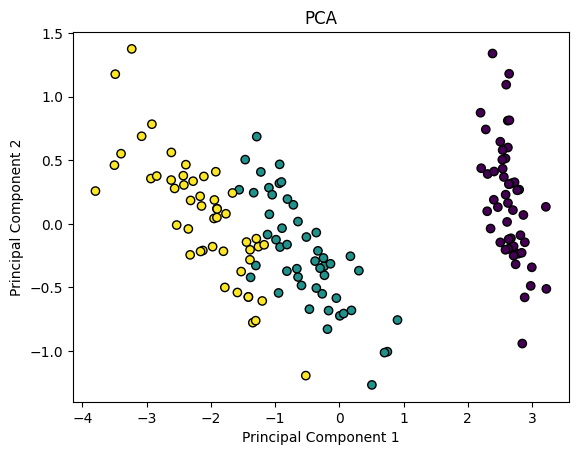

In [117]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualize X_pca
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA')
plt.show()